# Data Cleaning - VNExpress News Dataset

Dataset được crawl từ hai chuyên mục:

- Sức khỏe
- Giải trí

Notebook này thực hiện:

1. Kiểm tra dữ liệu thô
2. Làm sạch dữ liệu
3. Chuẩn hóa định dạng
4. Tạo feature mới
5. Xuất dataset sạch để phân tích tiếp

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

## 2. Đọc dữ liệu thô

In [2]:
df = pd.read_csv("../data/vnexpress_raw_data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1184, 11)


,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url
0,Không khí lễ hội xuân một thế kỷ trước qua ảnh,Cảnh người dân tham gia lễ hội đền Hai Bà Trưn...,"Thứ sáu, 27/2/2026, 00:00 (GMT+7)","Sân khấu - Mỹ thuật, Mỹ thuật",https://i1-giaitri.vnecdn.net/2026/02/24/den-h...,"Dịp đầu năm, nhiều lễ hội truyền thống được tổ...",Phương Linh,"lễ hội xuân, thế kỷ 20, ảnh xưa",Khác,0,https://vnexpress.net/khong-khi-le-hoi-xuan-mo...
1,Kanye West thừa nhận bị rối loạn tâm thần,Rapper Kanye West cho biết mắc rối loạn lưỡng ...,"Thứ ba, 27/1/2026, 15:04 (GMT+7)","Giới sao, Quốc tế",https://i1-giaitri.vnecdn.net/2026/01/27/kanye...,Trên trang quảng cáo của tờWall Street Journal...,Phương Thảo,"kanye west, rapper kanye west",Khác,0,https://vnexpress.net/kanye-west-thua-nhan-bi-...
2,Katy Perry quấn quýt cựu Thủ tướng Canada,Katy Perry và bạn trai - cựu Thủ tướng Justin ...,"Thứ tư, 11/2/2026, 10:49 (GMT+7)","Giới sao, Quốc tế",https://i1-giaitri.vnecdn.net/2026/02/11/Katy-...,"TrênInstagramngày 10/2, Katy Perry chia sẻ loạ...",Phương Thảo,"katy perry, justin trudeau, cựu thủ tướng cana...",Khác,5,https://vnexpress.net/katy-perry-quan-quyt-cuu...
3,Sỏi to 'bằng nắm tay' trong bàng quang người đ...,"TP HCMÔng Ngọc, 69 tuổi, có sỏi bàng quang 10 ...","Thứ ba, 10/3/2026, 08:00 (GMT+7)","Các bệnh, Tiết niệu - Nam học",https://i1-suckhoe.vnecdn.net/2026/03/09/anh-1...,Ông Ngọc đến Bệnh viện Đa khoa Tâm Anh TP HCM ...,Bảo Anh,"tp hcm, sỏi bàng quang, bệnh tiết niệu",Khác,3,https://vnexpress.net/soi-to-bang-nam-tay-tron...
4,Cuộc đua phim Việt Tết Bính Ngọ,Thị trường phim Việt sôi động với bốn tác phẩm...,"Thứ năm, 12/2/2026, 11:21 (GMT+7)","Phim, Chuyện màn ảnh",https://i1-giaitri.vnecdn.net/2026/01/30/phimt...,"Trước ngày khởi chiếu 17/2 (mùng Một Tết), bốn...",Cát Tiên,"trấn thành, thỏ ơi, nhà ba tôi một phòng, mùi ...",Khác,34,https://vnexpress.net/cuoc-dua-phim-viet-tet-b...


## 3. Thông tin dữ liệu

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1184 non-null   str  
 1   description       1177 non-null   str  
 2   date              1184 non-null   str  
 3   category          1184 non-null   str  
 4   thumbnail         1151 non-null   str  
 5   content           1184 non-null   str  
 6   author            1184 non-null   str  
 7   tags              1177 non-null   str  
 8   group             1184 non-null   str  
 9   nums_of_comments  1184 non-null   int64
 10  url               1184 non-null   str  
dtypes: int64(1), str(10)
memory usage: 101.9 KB


## 4. Kiểm tra dữ liệu thiếu

In [4]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df))*100
})

missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
thumbnail,33,2.787162
description,7,0.591216
tags,7,0.591216
title,0,0.000000
date,0,0.000000
category,0,0.000000
content,0,0.000000
author,0,0.000000
group,0,0.000000
nums_of_comments,0,0.000000


## 5. Phân bố dữ liệu ban đầu

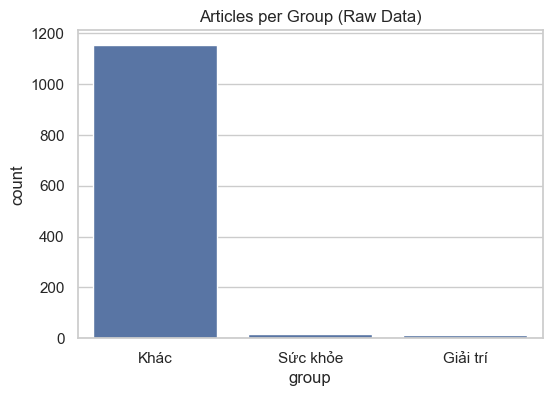

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="group")

plt.title("Articles per Group (Raw Data)")
plt.show()

# 6. Loại bỏ dữ liệu trùng lặp

In [6]:
print("Rows before:", len(df))

df = df.drop_duplicates(subset="url")

print("Rows after:", len(df))

Rows before: 1184
Rows after: 1184


## 7. Loại bỏ bài viết thiếu nội dung

In [7]:
df = df.dropna(subset=["title", "content"])

print("Rows after removing missing:", len(df))

Rows after removing missing: 1184


# 8. Làm sạch dữ liệu văn bản

In [8]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [9]:
df["title"] = df["title"].apply(clean_text)
df["content"] = df["content"].apply(clean_text)

## 9. Phân tích độ dài văn bản

In [10]:
df["title_length"] = df["title"].apply(lambda x: len(x.split()))
df["content_length"] = df["content"].apply(lambda x: len(x.split()))

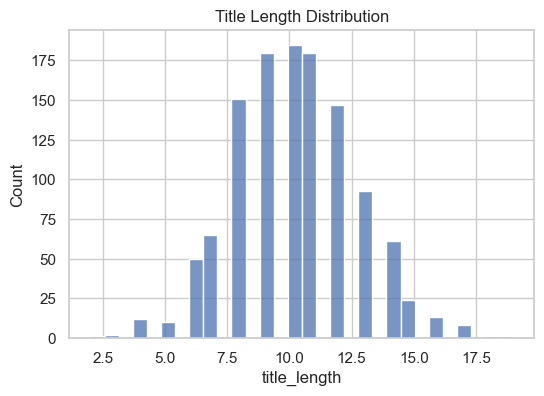

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

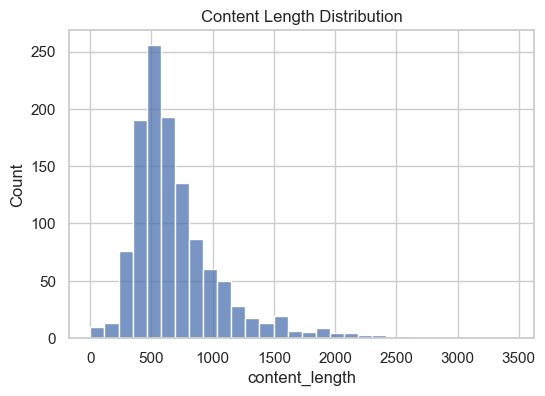

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

# 10. Chuẩn hóa định dạng ngày

In [13]:
def clean_date(text):

    if pd.isna(text):
        return text

    text = re.sub(r'^Thứ.*?,\s*', '', text)

    text = re.sub(r'\(.*?\)', '', text)

    return text.strip()

In [14]:
df["date"] = df["date"].apply(clean_date)

In [15]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y, %H:%M",
    errors="coerce"
)

## 11. Tạo feature thời gian

In [16]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

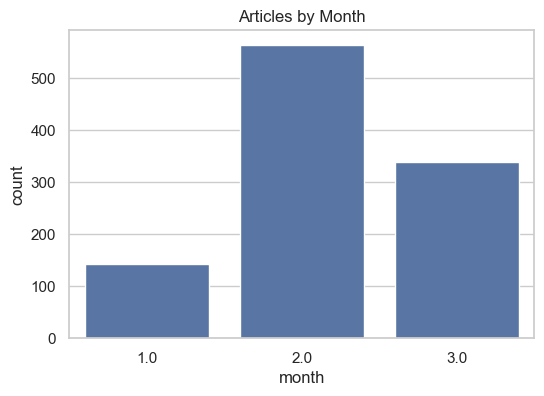

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="month")

plt.title("Articles by Month")

plt.show()

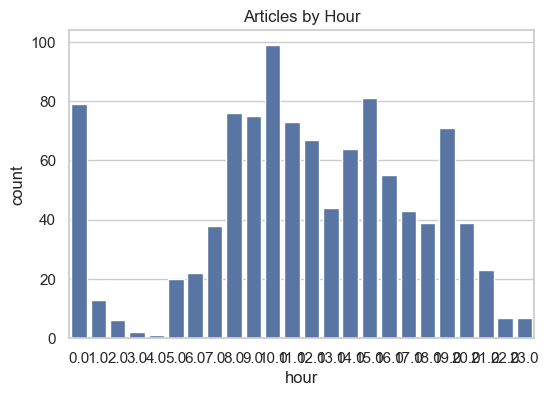

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="hour")

plt.title("Articles by Hour")

plt.show()

## 12. Phân tích số lượng bình luận

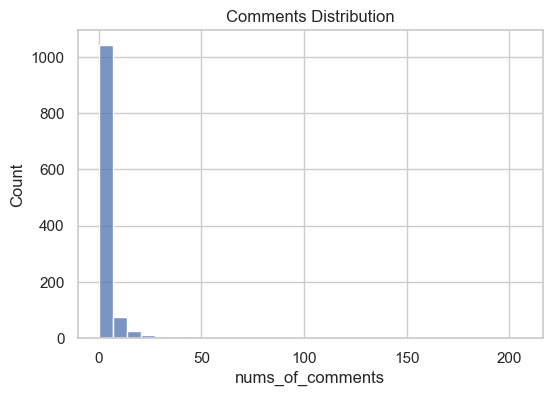

In [19]:
plt.figure(figsize=(6,4))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Comments Distribution")

plt.show()

## 13. Kiểm tra dataset sau khi clean

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             1184 non-null   str           
 1   description       1177 non-null   str           
 2   date              1044 non-null   datetime64[us]
 3   category          1184 non-null   str           
 4   thumbnail         1151 non-null   str           
 5   content           1184 non-null   str           
 6   author            1184 non-null   str           
 7   tags              1177 non-null   str           
 8   group             1184 non-null   str           
 9   nums_of_comments  1184 non-null   int64         
 10  url               1184 non-null   str           
 11  title_length      1184 non-null   int64         
 12  content_length    1184 non-null   int64         
 13  year              1044 non-null   float64       
 14  month             1044 non-null   f

In [21]:
df.describe()

,date,nums_of_comments,title_length,content_length,year,month,hour
count,1044,1184.000000,1184.000000,1184.000000,1044.0,1044.000000,1044.000000
mean,2026-02-21 00:22:57.241379,3.214527,10.208615,700.580236,2026.0,2.187739,11.816092
min,2026-01-19 20:31:00,0.000000,2.000000,2.000000,2026.0,1.000000,0.000000
25%,2026-02-13 18:15:00,0.000000,9.000000,464.000000,2026.0,2.000000,9.000000
50%,2026-02-24 15:00:00,0.000000,10.000000,599.000000,2026.0,2.000000,12.000000
75%,2026-03-03 18:00:00,2.000000,12.000000,816.000000,2026.0,3.000000,16.000000
max,2026-03-10 20:52:00,206.000000,19.000000,3454.000000,2026.0,3.000000,23.000000
std,NaN,12.137892,2.458011,380.116831,0.0,0.651867,5.590251


## 14. Lưu dataset đã clean

In [22]:
df.to_csv("../data/vnexpress_clean_data.csv", index=False)

print("Saved clean dataset")

Saved clean dataset
